### Proceso de limpieza EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [3]:
# Carga del dataset
df_raw = pd.read_csv('C:/Users/fabia/Documents/GitHub/Prediccion-rendimiento-academico/DATA/PROCESSED/student_model_processed.csv')

print(f"Registros: {df_raw.shape[0]}")
print(f"Columnas:  {df_raw.shape[1]}")

Registros: 1044
Columnas:  35


In [4]:
df_raw.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,subject,G3,risk_level
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,math,6,Riesgo alto
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,math,6,Riesgo alto
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,math,10,Riesgo bajo
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,math,15,Sin riesgo
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,math,10,Riesgo bajo


In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

### Nulos

In [6]:
df_raw.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
subject       0
G3            0
risk_level    0
dtype: int64

### Duplicados

In [7]:
df_raw.duplicated().sum()

np.int64(0)

### Stats basicas

In [8]:
df_raw.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1044.0,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
Medu,1044.0,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
traveltime,1044.0,1.522989,0.731727,1.0,1.0,1.0,2.0,4.0
studytime,1044.0,1.970307,0.834353,1.0,1.0,2.0,2.0,4.0
failures,1044.0,0.264368,0.656142,0.0,0.0,0.0,0.0,3.0
famrel,1044.0,3.935824,0.933401,1.0,4.0,4.0,5.0,5.0
freetime,1044.0,3.201149,1.031507,1.0,3.0,3.0,4.0,5.0
goout,1044.0,3.156130,1.152575,1.0,2.0,3.0,4.0,5.0
Dalc,1044.0,1.494253,0.911714,1.0,1.0,1.0,2.0,5.0


### Se crea la variable objetivo para el modelo 2
### Multiclase: Clasificar nivel de riesgo académico (Sin riesgo/Riesgo bajo/Riesgo medio/Riesgo alto)

## G3 es la variable objetivo que ya trae el dataset, ya que es la nita final de los estudiantes

In [9]:
def obj_riesgo(g3):
    if g3 >= 14:   return 'Sin riesgo'
    elif g3 >= 10: return 'Riesgo bajo'
    elif g3 >= 7:  return 'Riesgo medio'
    else:          return 'Riesgo alto'

df_raw['risk_level'] = df_raw['G3'].apply(obj_riesgo)

risk_order = ['Sin riesgo', 'Riesgo bajo', 'Riesgo medio', 'Riesgo alto']
df_raw['risk_level'] = pd.Categorical(df_raw['risk_level'], categories=risk_order, ordered=True)

print(df_raw['risk_level'].value_counts().sort_index())

risk_level
Sin riesgo      294
Riesgo bajo     520
Riesgo medio    149
Riesgo alto      81
Name: count, dtype: int64


## La suma de estudiantes de riesgo medio y alto suman el mismo total que da la data inicial (230)

# VISUALIZACIONES

# *importante*
## G3 REPRESENTA LAS NOTAS TOTALES DE LOS ESTUDIANTES A FINAL DE CURSO

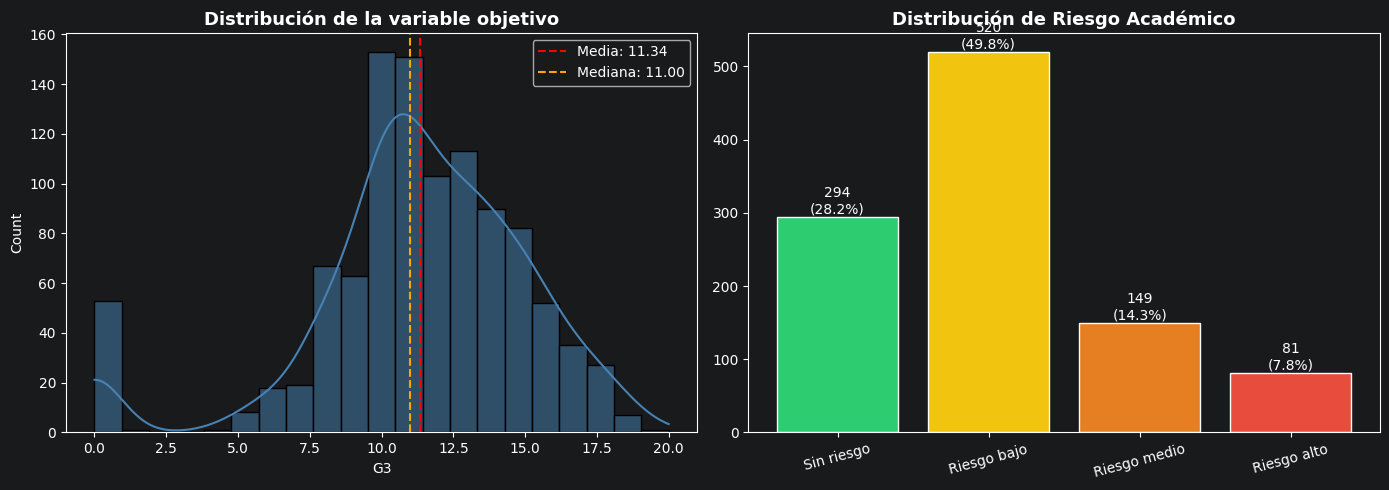

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1
# G3 (objetivo)
sns.histplot(df_raw['G3'], bins=21, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df_raw['G3'].mean(), color='red', linestyle='--', label=f'Media: {df_raw["G3"].mean():.2f}')
axes[0].axvline(df_raw['G3'].median(), color='orange', linestyle='--', label=f'Mediana: {df_raw["G3"].median():.2f}')
axes[0].set_title('Distribución de la variable objetivo', fontsize=13, fontweight='bold')
axes[0].legend()

# Grafico 2
# Riesgo académico
risk_order = ['Sin riesgo', 'Riesgo bajo', 'Riesgo medio', 'Riesgo alto']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
counts = df_raw['risk_level'].value_counts().reindex(risk_order)

axes[1].bar(range(len(risk_order)), counts.values, color=colors, edgecolor='white')
axes[1].set_xticks(range(len(risk_order)))
axes[1].set_xticklabels(risk_order, rotation=15)
axes[1].set_title('Distribución de Riesgo Académico', fontsize=13, fontweight='bold')
for i, val in enumerate(counts.values):
    axes[1].text(i, val + 5, f'{val}\n({val/len(df_raw)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### La mayoria de los estudiantes tienen un rendimiento promedio
### hay almumnos en riesgo que no se presentan a los examenes finales, ya que presentan un 0

## SEPARAR VARIABLES DE CATEGORICAS A NUMERICAS

In [11]:
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()

feature_num = [c for c in num_cols if c not in ['G3']]
feature_cat = [c for c in cat_cols if c not in ['risk_level', 'subject']]

print(f"Variables numéricas: {feature_num}")
print(f"Variables categóricas: {feature_cat}")

Variables numéricas: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Variables categóricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\fabia\AppData\Local\Temp\ipykernel_32468\3765923090.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()


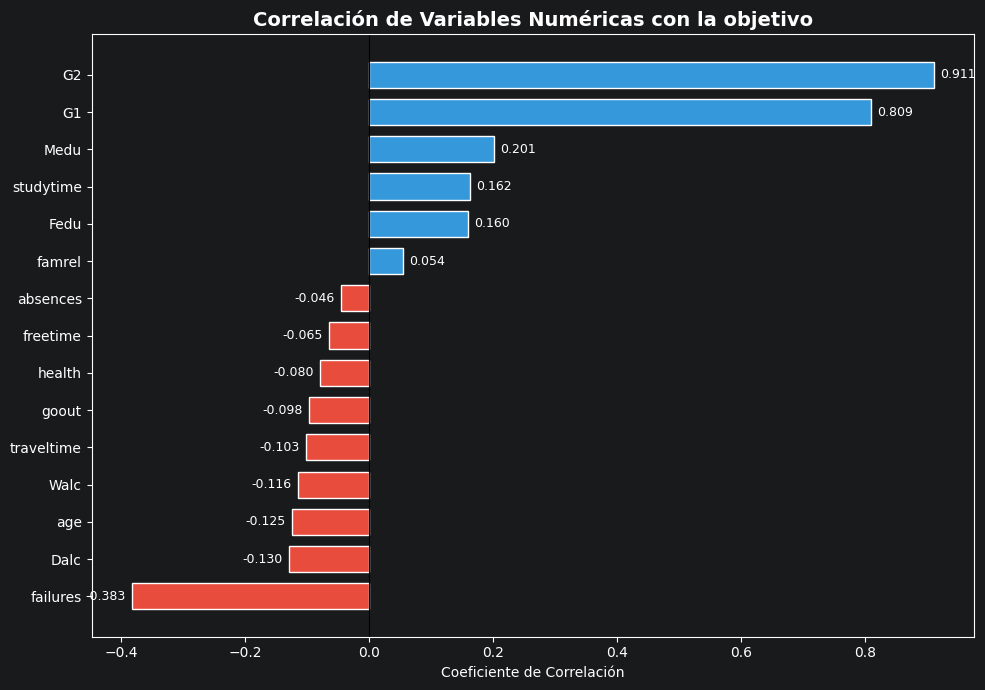

In [12]:
corr_g3 = df_raw[feature_num + ['G3']].corr()['G3'].drop('G3').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in corr_g3.values]
ax.barh(corr_g3.index, corr_g3.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Variables Numéricas con la objetivo', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlación')
for i, (idx, val) in enumerate(corr_g3.items()):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

# CORRELACIONES POSITIVAS

### G1 Y G2 son las notas del primer y segundo trimestre
### MEDU (Educacion de la madre)
### FEDU (Educacion del padre)
### STUDYTIME (tiempo de estudio)

# CORRELACIONES NEGATIVAS

### Failures (reprobaciones)
### DALC (consumo del alcohol entre semana)
### AGE (edad - a mayor edad menos rendimiento)

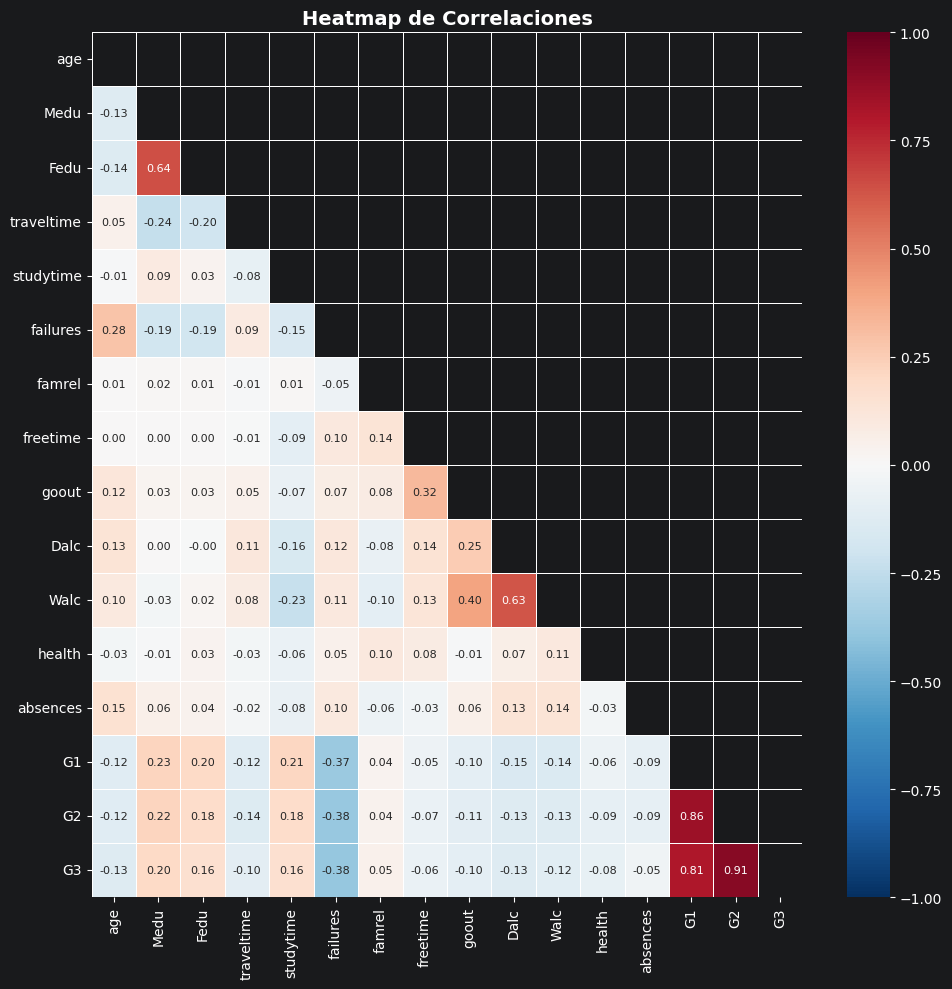

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

corr_matrix = df_raw[feature_num + ['G3']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)

ax.set_title('Heatmap de Correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\fabia\AppData\Local\Temp\ipykernel_32468\436910572.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=df_raw, order=order, ax=ax,
C:\Users\fabia\AppData\Local\Temp\ipykernel_32468\436910572.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=df_raw, order=order, ax=ax,
C:\Users\fabia\AppData\Local\Temp\ipykernel_32468\436910572.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='G3', data=df_raw, order=order, ax=ax,
C:\Users\fabia\AppData\Local\Temp\ipykernel_32468\436910572.py:7: F

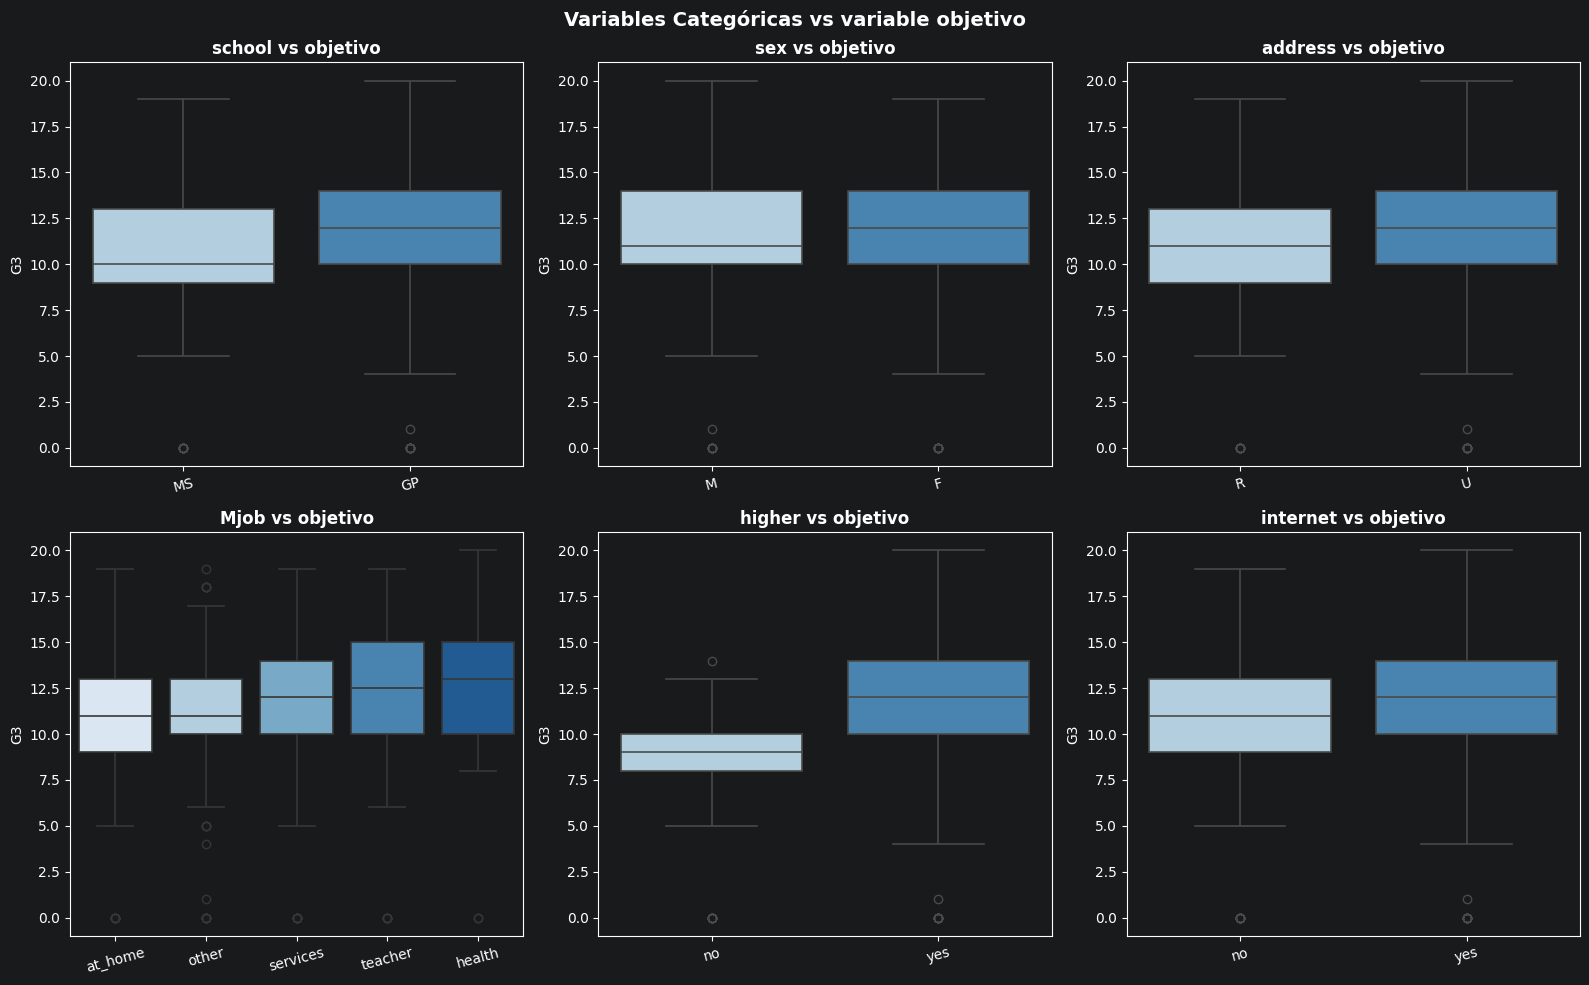

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

key_cat = ['school', 'sex', 'address', 'Mjob', 'higher', 'internet']

for ax, col in zip(axes.flatten(), key_cat):
    order = df_raw.groupby(col)['G3'].median().sort_values().index
    sns.boxplot(x=col, y='G3', data=df_raw, order=order, ax=ax,
                palette='Blues', linewidth=1.2)
    ax.set_title(f'{col} vs objetivo', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.set_xlabel('')

plt.suptitle('Variables Categóricas vs variable objetivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### higher = Estudiantes que quieren ir a la universidad
### mjob = madres en el sector de la salud y docencia tienen hijos con mejores notas que las madre en casa
### internet = estudiantes con internet tienen mejor rendimiento
### school = GP tiene mediana mas alta que el MS (Mejor educacion)

# OUTLIERS

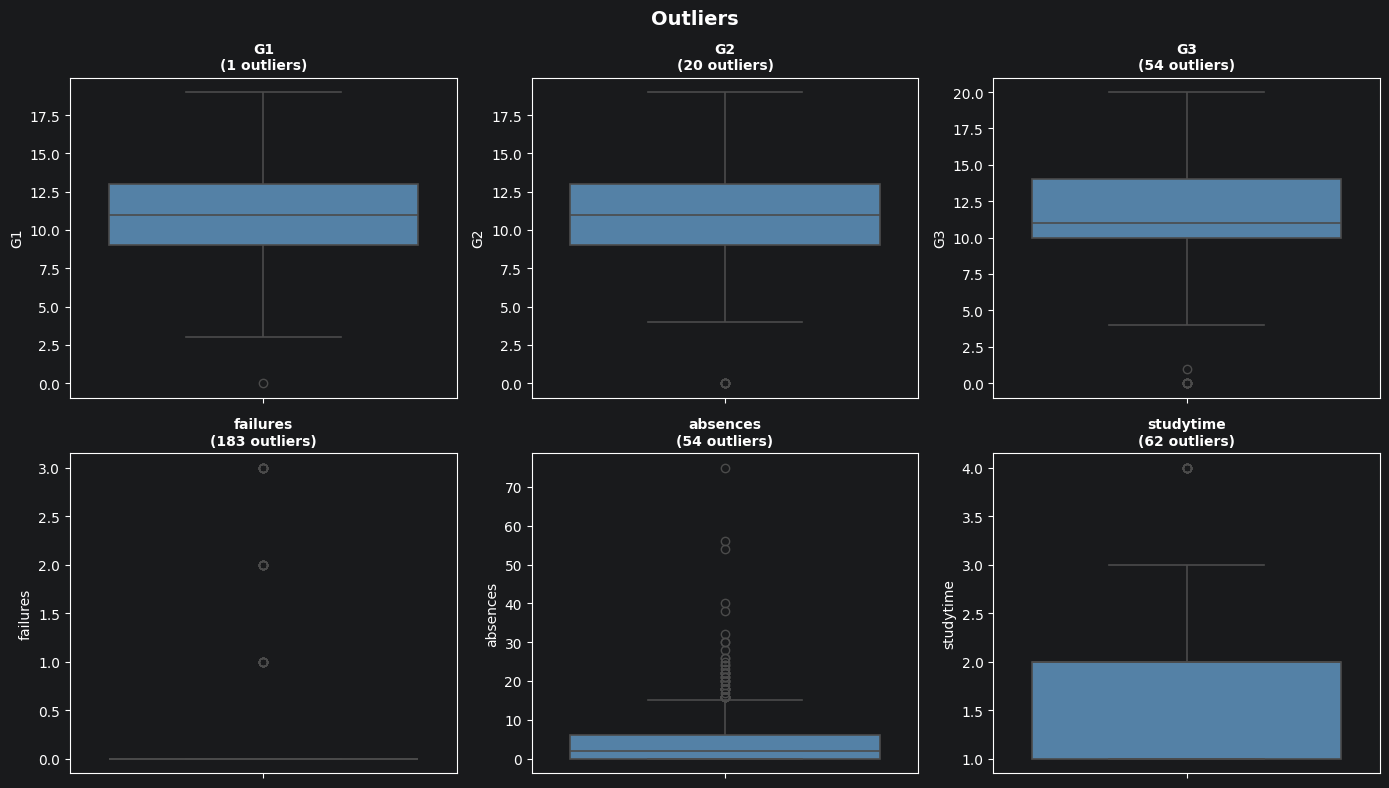

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

key_num = ['G1', 'G2', 'G3', 'failures', 'absences', 'studytime']

for i, col in enumerate(key_num):
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()

    sns.boxplot(y=df_raw[col], ax=axes[i], color='steelblue', linewidth=1.2)
    axes[i].set_title(f'{col}\n({n_out} outliers)', fontsize=10, fontweight='bold')

plt.suptitle('Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### G3 los estudianets en peligro
### Failures Estudiantes reprobados
### absences son las ausensias de los estudiantes
### studytime el tiempo de estudio

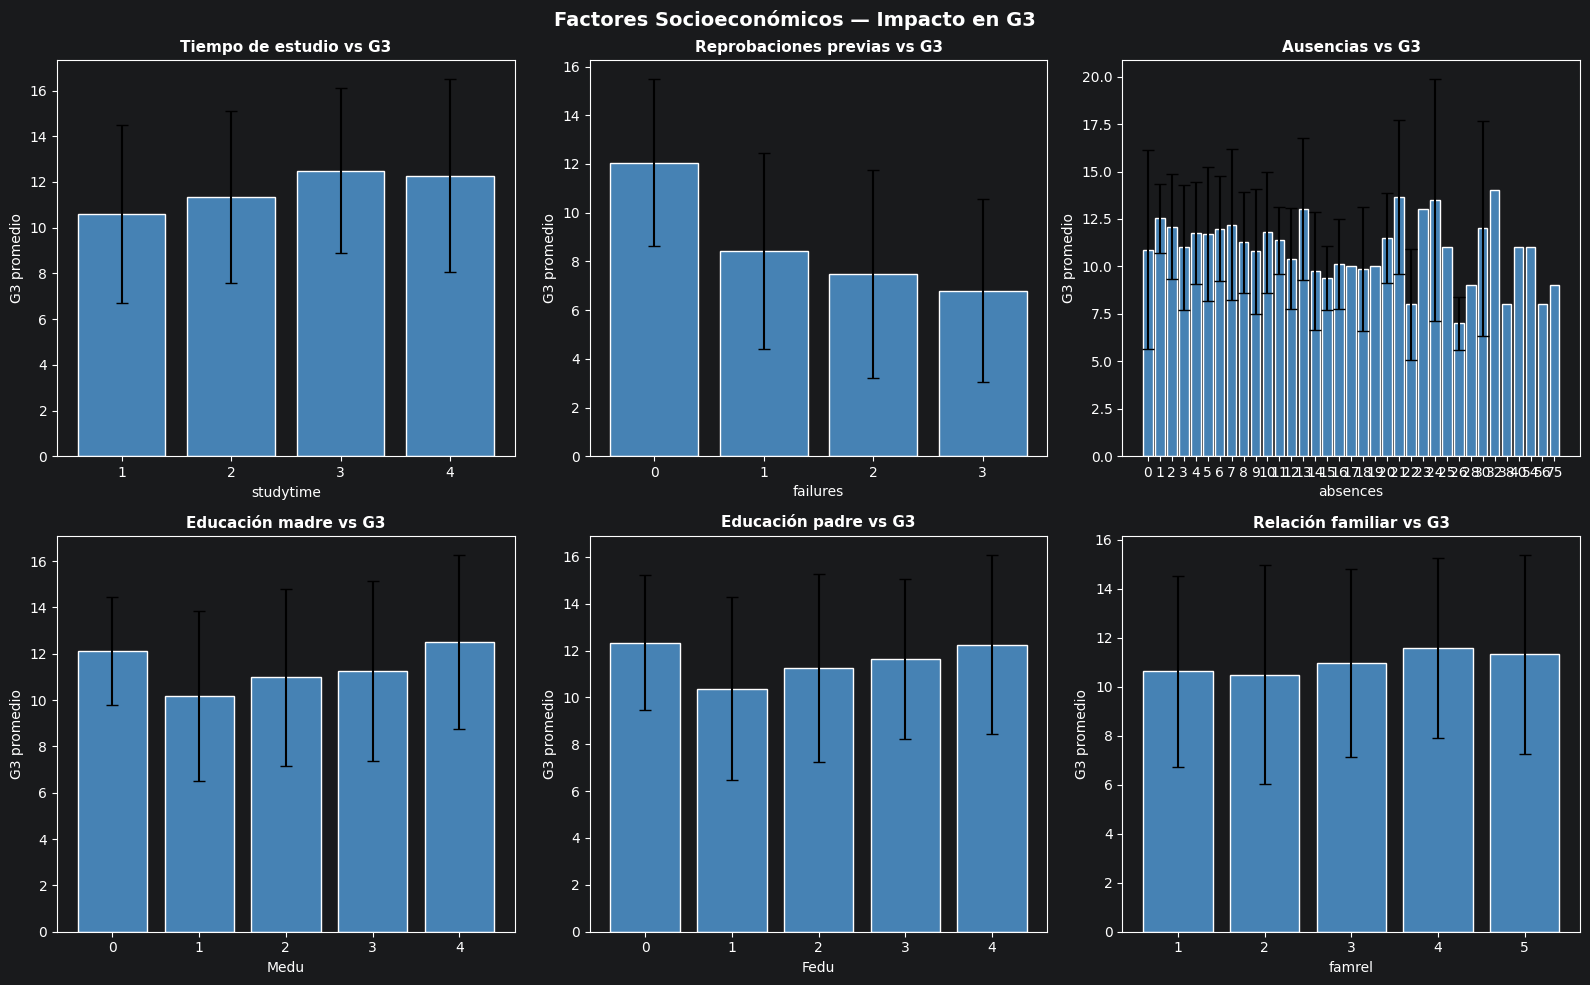

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

social_vars = [
    ('studytime', 'Tiempo de estudio'),
    #
    ('failures', 'Reprobaciones previas'),
    ('absences', 'Ausencias'),
    ('Medu', 'Educación madre'),
    ('Fedu', 'Educación padre'),
    ('famrel', 'Relación familiar'),
]

for ax, (col, label) in zip(axes.flatten(), social_vars):
    means = df_raw.groupby(col)['G3'].mean()
    stds  = df_raw.groupby(col)['G3'].std()
    ax.bar(means.index.astype(str), means.values, color='steelblue',
           yerr=stds.values, capsize=4, edgecolor='white')
    ax.set_title(f'{label} vs G3', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('G3 promedio')

plt.suptitle('Factores Socioeconómicos — Impacto en G3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## TIEMPO DE ESTUDIO SEMANAL
### 1 = Menos de 2 horas
### 2 = Entre 2 y 5 horas
### 3 = Entre 5 y 10 horas
### 4 = Más de 10 horas

## EDUCACION PADRE Y MADRE
### 0 = sin educacion
### 1 = educacion Primaria
### 2 = 5to a 9no grado
### 3 = Secundaria completa
### 4 = Universidad


## FAMREL(RELACION FAMILIAR)
### 1 = Muy mal
### 2 = Mala
### 3 = Regular
### 4 = Buena
### 5 = Muy buena

# PREPARACION DEL MODELO

In [18]:
# Variables a excluir para el modelo
exclude = ['G3', 'risk_level']
df_model = df_raw.drop(columns=exclude).copy()

# Agregar las variables que el modelo tiene que predecir
df_model['G3'] = df_raw['G3']
df_model['risk_level'] = df_raw['risk_level'].astype(str)

print(f"Shape final: {df_model.shape}")
print(f"\nVariables categóricas para onehotencoding: {feature_cat}")
print(f"\nVariables numéricas: {feature_num}")

Shape final: (1044, 35)

Variables categóricas para onehotencoding: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Variables numéricas: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


## GUARDAR EL CSV LISTO

In [19]:

df_model.to_csv('../DATA/PROCESSED/student_model_processed.csv', index=False)
print("\n✓ Guardado: DATA/PROCESSED/student_model_processed.csv")

OSError: Cannot save file into a non-existent directory: '..\DATA\PROCESSED'